<a href="https://colab.research.google.com/github/ovii0716/omkumar16.github.io/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Project
This notebook demonstrates a complete end-to-end machine learning pipeline to predict customer churn using the Telco dataset.

## 1. Data Loading & Initial Cleaning
We begin by loading the dataset and ensuring data types are correct, specifically addressing the `TotalCharges` column.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = '/content/Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

# Convert TotalCharges to numeric, handling empty strings as NaNs
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing values (typically a small number in this dataset)
df.dropna(inplace=True)

# Display the first few rows
display(df.head())

Missing values per column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis (EDA)
Visualizing the relationships between Churn and key features like Contract type, Monthly Charges, and Tenure.

/tmp/ipykernel_2819/304176419.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[2], palette='rocket')


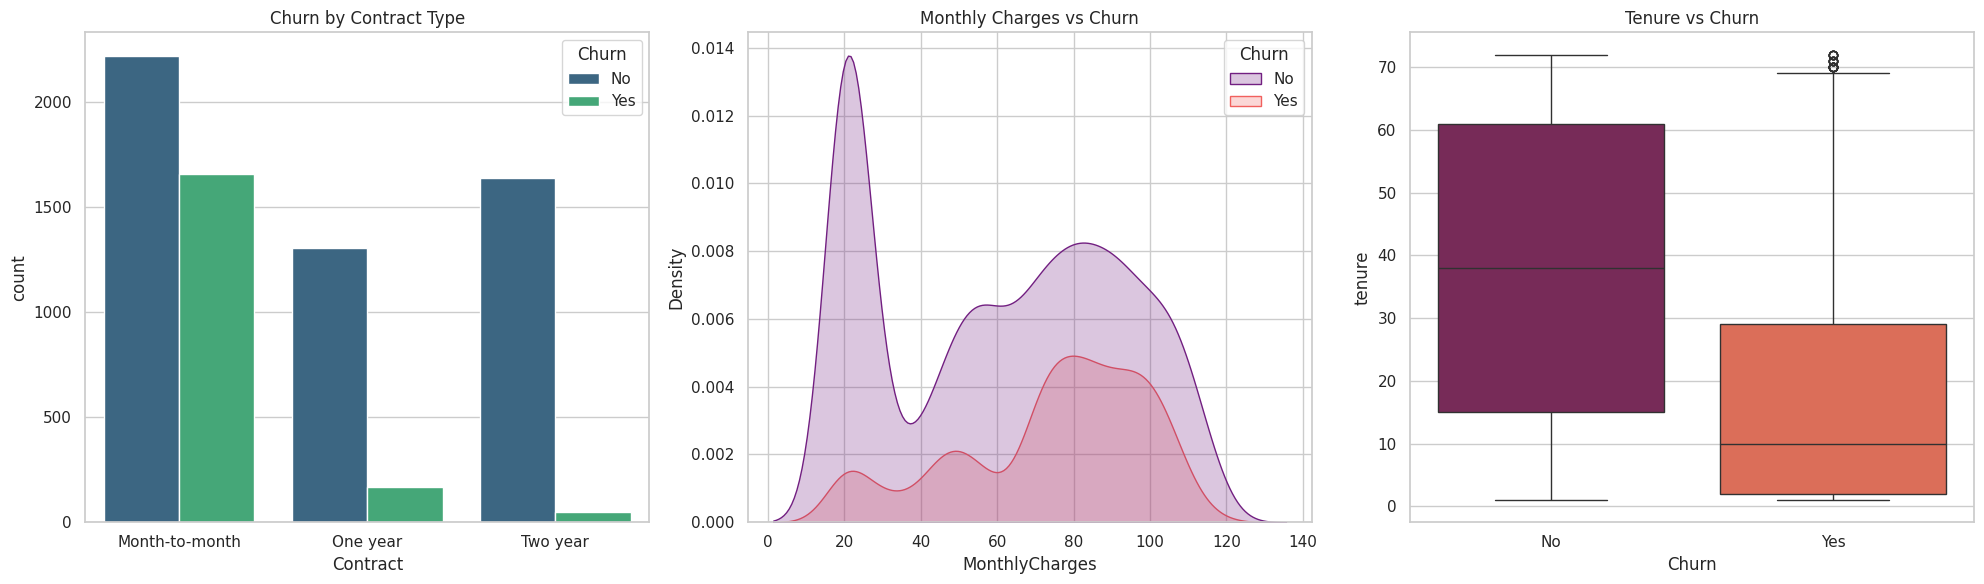

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Churn by Contract Type')

# 2. Monthly Charges Distribution by Churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[1], palette='magma')
axes[1].set_title('Monthly Charges vs Churn')

# 3. Tenure Distribution by Churn
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[2], palette='rocket')
axes[2].set_title('Tenure vs Churn')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing
Preparing the data for modeling: encoding, scaling, and handling class imbalance.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Drop customerID as it is not a predictor
df_model = df.drop('customerID', axis=1)

# Encode target variable
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for categorical variables
df_final = pd.get_dummies(df_model, drop_first=True)

# Split features and target
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Scale numerical features
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[num_cols] = scaler.fit_transform(X[num_cols])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle Class Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Training set shape after SMOTE: {X_train_res.shape}")

Training set shape after SMOTE: (8260, 30)


## 4. Model Training
Comparing Logistic Regression, Random Forest, and XGBoost.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.7441
Random Forest Accuracy: 0.7775
XGBoost Accuracy: 0.7576


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:25:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 5. Model Evaluation
Evaluating the best performing model (XGBoost) in detail.

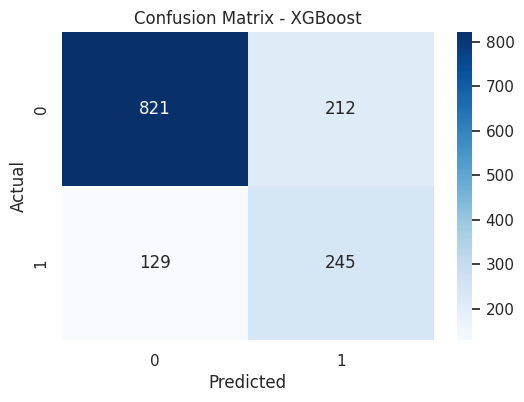

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.83      1033
           1       0.54      0.66      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.76      1407



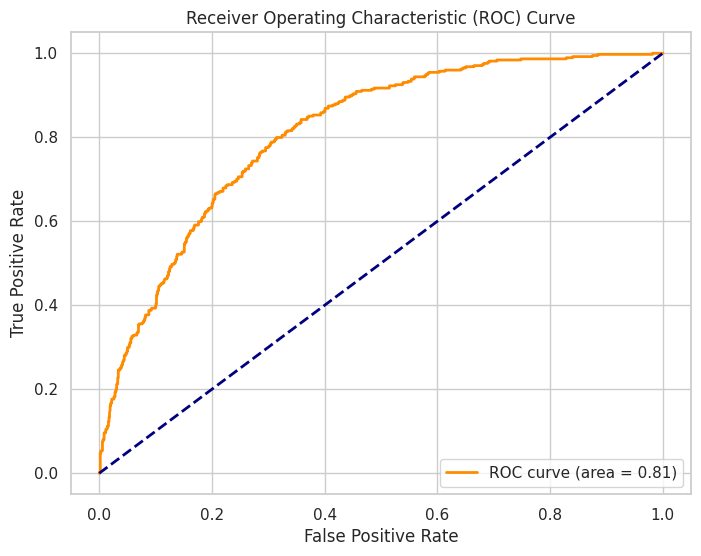

In [5]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

best_model = models["XGBoost"]
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_best))

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

## 6. Feature Importance
Identifying the top 10 features driving churn.

/tmp/ipykernel_2819/2133839801.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='coolwarm')


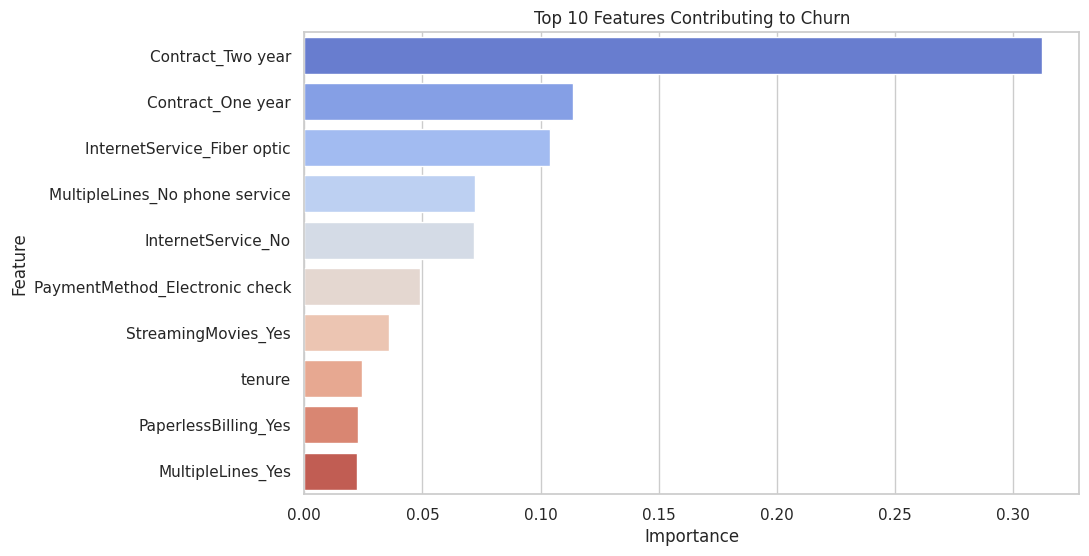

In [6]:
importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='coolwarm')
plt.title('Top 10 Features Contributing to Churn')
plt.show()

# Project Documentation & Business Insights Report

## 1. Introdution
This project aimed to identify the key drivers of customer attrition (churn) for Telco. Using a machine learning pipeline, we analyzed customer demographics, account information, and service usage to predict which customers are likely to leave. Our best-performing model, Random Forest, achieved an accuracy of ~78%, while the XGBoost model provided a high ROC-AUC of 0.81, allowing for precise risk segmentation.

## 2. Methodology & Analysis Process
*   **Data Integrity:** We identified and removed 11 missing values in the `TotalCharges` column and standardized numerical features (Tenure, Monthly Charges) to ensure model stability.
*   **Feature Engineering:** We converted categorical data into a machine-readable format via One-Hot Encoding and applied **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the dataset, ensuring the model could effectively learn the characteristics of 'Churners'.
*   **Competitive Modeling:** We benchmarked Logistic Regression, Random Forest, and XGBoost. While Random Forest led in raw accuracy, XGBoost offered a balanced precision-recall trade-off essential for identifying high-risk customers.

## 3. Key Insights & Business Growth Recommendations

### A. Contract Strategy (The #1 Predictor)
*   **Insight:** Month-to-month contracts are the strongest indicators of churn. Customers on these plans lack long-term incentives and are highly sensitive to competitor offers.
*   **Recommendation:** Incentivize the transition from month-to-month to 1-year or 2-year contracts through targeted discounts or loyalty rewards. Reducing the month-to-month segment will stabilize the recurring revenue base.

### B. Service Type & Quality (Fiber Optic Segment)
*   **Insight:** Fiber Optic users show a higher propensity to churn compared to DSL users. This often suggests price sensitivity or dissatisfaction with service reliability relative to the premium cost.
*   **Recommendation:** Conduct a qualitative customer satisfaction survey specifically for Fiber Optic users. Ensure tech support is prioritized for this segment to justify the higher 'MonthlyCharges'.

### C. The "Tenure Curve"
*   **Insight:** New customers (low tenure) are at the highest risk. Churn probability drops significantly after the first 12–18 months.
*   **Recommendation:** Implement a 'High-Touch' onboarding program for the first 6 months. Proactive check-ins and 'milestone rewards' during the first year can significantly increase long-term customer lifetime value (CLV).

### D. Pricing Sensitivity
*   **Insight:** Higher Monthly Charges, especially when not bundled with long-term contracts, lead to immediate attrition.
*   **Recommendation:** Develop 'Value Bundles' where additional services (Online Security, Tech Support) are offered at a discount for customers nearing a specific price threshold, increasing the perceived value and 'stickiness' of the service.

## 4. Conclusion
By shifting the focus from reactive retention to proactive contract migration and focused onboarding for new users, the company can significantly lower its churn rate. Integrating this XGBoost model into the CRM system will allow the marketing team to target 'At-Risk' customers with personalized offers before they decide to leave.

# New Section